# Notebook 1 — Data Overview

**Goal:** Load the CSV files from the pipeline, understand what the data looks like, check for missing values, and visualize the distributions.

This notebook explores the output of the robocode-autopilot pipeline — CSV files generated from battle recordings. We have three types of files:

- **ticks.csv** — One row per game tick (like a frame in a video). Each row records what the robot could observe at that moment: distances, velocities, angles, energy levels. **No per-battle constants here** — keeping ticks lean (every column ≈ 8 bytes × millions of rows).
- **waves.csv** — One row per detected opponent fire. A snapshot of bullet power, speed, the distance at which the bullet was fired, the maximum escape angle (MEA), and our lateral velocity at fire instant.
- **scores.csv** — One row per round. Records the round outcome (damage dealt/received, hit rates, win) **plus per-battle constants** (opponent identity hashes, battlefield dimensions, gun cooling rate, total rounds). The constants are identical across all rounds of a battle — deduplicate via `scores.drop_duplicates('battle_id')` if you only need the constants once.

> **What is a DataFrame?** Think of it like a spreadsheet. Rows are observations (one per game tick), columns are measurements (features like distance, velocity, etc.). pandas is the Python library that gives us these spreadsheet-like tools.
>
> **Why split per-battle constants out of ticks.csv?** A value that never changes across a battle (like `battlefield_width`) repeated 3,000 times per battle wastes ~24 KB per battle × thousands of battles. Putting it in scores.csv (≤35 rows/battle) and joining when needed costs ~280 bytes per battle. Use `attach_battle_constants(ticks, scores)` from `_loader` to merge them on demand.


In [1]:
# --- Setup ---
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _loader import build_robot_index, load_stratified

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# --- Data sampling strategy ---
# The full dataset is ~20 GB of ticks.csv across ~1900 battles. Naive loading
# OOMs VS Code's notebook host. Strategy: STRATIFIED per-robot sampling —
# pick top-N most-played robots × N battles each × row-subsample each file.
# Numeric columns are downcast (float64→float32, int64→int32) to halve RAM.
# See `intuition/_loader.py` — same helper used by every notebook in this folder.
selection = build_robot_index(max_robots=50, battles_per_robot=3, seed=42)

ticks  = load_stratified("ticks.csv",  selection, row_frac=0.20)
waves  = load_stratified("waves.csv",  selection)   # small, keep all rows
scores = load_stratified("scores.csv", selection)   # tiny, keep all rows

# Sanity check: rows per robot in ticks
print("\nRows per robot in ticks (top 5 / bottom 5):")
counts = ticks['robot_name'].value_counts()
print(counts.head(5).to_string())
print("...")
print(counts.tail(5).to_string())


Indexed 1942 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~3 battles = 150 (battle, robot) pairs to load.


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 150 ticks.csv files → 998,274 rows × 87 cols, 50 robots (~422.1 MB)


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 150 waves.csv files → 275,919 rows × 13 cols, 50 robots (~45.9 MB)


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 150 scores.csv files → 5,250 rows × 17 cols, 50 robots (~0.9 MB)

Rows per robot in ticks (top 5 / bottom 5):
robot_name
Firestarter 2.0f               58160
BeepBoop 2.0                   38319
ScalarR 0.005h.053-noshield    33903
Roborio 1.2.4                  32330
Neuromancer 7.12               30838
...
robot_name
Pris 0.92                  15109
Midboss 1q.fast            14909
Ascendant 1.2.27           14710
SilverSurfer 2.53.33fix    14554
deBroglie rev0108          14547


In [2]:
# --- Quick look at each DataFrame ---
print("=" * 60)
print("TICKS.CSV — one row per game tick per robot perspective")
print("=" * 60)
print(f"Shape: {ticks.shape[0]:,} rows × {ticks.shape[1]} columns")
print(f"\nColumn names:\n{list(ticks.columns)}")
print(f"\nData types:\n{ticks.dtypes}")
print(f"\nFirst 3 rows:")
ticks.head(3)

TICKS.CSV — one row per game tick per robot perspective
Shape: 998,274 rows × 87 columns

Column names:
['battle_id', 'round', 'tick', 'scan_available', 'distance', 'bearing_to_opponent_abs', 'opponent_dist_to_wall_min', 'our_gun_heat', 'ticks_since_scan', 'our_x', 'our_y', 'our_heading', 'our_velocity', 'opponent_x', 'opponent_y', 'opponent_heading', 'cumulative_damage_dealt', 'cumulative_damage_received', 'cumulative_our_hit_rate', 'cumulative_opponent_hit_rate', 'cumulative_our_shots_fired', 'cumulative_opponent_shots_detected', 'opponent_energy', 'opponent_fired', 'opponent_fire_power', 'opponent_center_distance', 'opponent_corner_proximity', 'ticks_between_scans', 'scan_coverage_20', 'scan_coverage_50', 'scan_arc_width', 'radar_locked', 'radar_turn_direction', 'opponent_velocity', 'opponent_lateral_velocity', 'opponent_advancing_velocity', 'opponent_heading_delta', 'energy_ratio', 'our_lateral_velocity', 'our_dist_to_wall_min', 'our_bullet_speed', 'our_bullet_travel_time', 'mea_fo

,battle_id,round,tick,scan_available,distance,bearing_to_opponent_abs,opponent_dist_to_wall_min,our_gun_heat,ticks_since_scan,our_x,...,gf_current_at_power_1_5,gf_current_at_power_2,opponent_guess_factor,opponent_avg_lateral_velocity_10,opponent_avg_lateral_velocity_30,opponent_heading_delta_variability_10,opponent_velocity_variability_10,opponent_time_since_velocity_change,opponent_distance_since_direction_change,robot_name
0,020e2202,26,397,1,507.342010,5.4492,90.661003,1.29,0,466.407990,...,0.3755,0.3348,-0.4849,0.2912,1.0855,0.009679,0.6403,6.0,258.0,ScalarR 0.005h.053-noshield
1,020e2202,8,761,0,NaN,NaN,NaN,0.00,52,49.243999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ScalarR 0.005h.053-noshield
2,020e2202,1,678,1,445.549011,0.0959,118.641998,0.92,0,187.656998,...,-0.5535,-0.4935,0.9973,-4.3913,-1.9381,0.010204,2.7276,1.0,204.0,ScalarR 0.005h.053-noshield


In [3]:
print("=" * 60)
print("WAVES.CSV — one row per bullet fired")
print("=" * 60)
print(f"Shape: {waves.shape[0]:,} rows × {waves.shape[1]} columns")
print(f"\nColumn names:\n{list(waves.columns)}")
display(waves.head(3))

print("\n" + "=" * 60)
print("SCORES.CSV — one row per round")
print("=" * 60)
print(f"Shape: {scores.shape[0]:,} rows × {scores.shape[1]} columns")
print(f"\nColumn names:\n{list(scores.columns)}")
display(scores.head(3))

WAVES.CSV — one row per bullet fired
Shape: 275,919 rows × 13 columns

Column names:
['battle_id', 'round', 'tick', 'wave_bullet_power', 'wave_bullet_speed', 'wave_fire_distance', 'wave_mea', 'wave_flight_time', 'wave_lateral_velocity_at_fire', 'our_x_at_fire', 'our_y_at_fire', 'opponent_heading_at_fire', 'robot_name']


,battle_id,round,tick,wave_bullet_power,wave_bullet_speed,wave_fire_distance,wave_mea,wave_flight_time,wave_lateral_velocity_at_fire,our_x_at_fire,our_y_at_fire,opponent_heading_at_fire,robot_name
0,020e2202,0,45,1.9,14.3,468.338013,0.593711,32.750000,7.912,236.195007,511.463989,4.726141,ScalarR 0.005h.053-noshield
1,020e2202,0,59,1.9,14.3,506.915009,0.593711,35.450001,7.999,132.201996,474.263000,4.474338,ScalarR 0.005h.053-noshield
2,020e2202,0,87,1.9,14.3,451.946014,0.593711,31.600000,-7.852,91.873001,416.253998,4.543454,ScalarR 0.005h.053-noshield



SCORES.CSV — one row per round
Shape: 5,250 rows × 17 columns

Column names:
['battle_id', 'round', 'ticks_in_round', 'damage_dealt', 'damage_received', 'net_damage', 'our_hit_rate', 'opponent_hit_rate', 'win_rate', 'opponent_name_hash', 'opponent_bot_id_hash', 'opponent_version_hash', 'battlefield_width', 'battlefield_height', 'gun_cooling_rate', 'num_rounds_total', 'robot_name']


,battle_id,round,ticks_in_round,damage_dealt,damage_received,net_damage,our_hit_rate,opponent_hit_rate,win_rate,opponent_name_hash,opponent_bot_id_hash,opponent_version_hash,battlefield_width,battlefield_height,gun_cooling_rate,num_rounds_total,robot_name
0,020e2202,0,778,48.799999,37.599998,11.200000,0.1739,0.1053,1.0000,1590568563,2029393366,1938043400,800,600,0.1,35,ScalarR 0.005h.053-noshield
1,020e2202,1,1012,13.700000,57.400002,-43.700001,0.1618,0.1538,0.5000,1590568563,2029393366,1938043400,800,600,0.1,35,ScalarR 0.005h.053-noshield
2,020e2202,2,1083,14.600000,26.340000,-11.740000,0.0972,0.0517,0.6667,1590568563,2029393366,1938043400,800,600,0.1,35,ScalarR 0.005h.053-noshield


## Section 3 — Descriptive Statistics

Here's what each number in `.describe()` means:

| Statistic | What it means | Analogy |
|-----------|---------------|---------|
| **count** | How many non-NaN values | How many times we actually measured this |
| **mean** | Sum of all values ÷ count. The "average" | If you split all the pizza equally, how much each person gets |
| **std** | Standard deviation — how spread out values are from the mean | Small std = everyone got similar amounts. Large std = some got a lot, some got little |
| **min** | Smallest value | The shortest kid in class |
| **25%** | 25th percentile — 25% of values are below this | A quarter of the class is shorter than this |
| **50%** | Median — the middle value when sorted. Not fooled by extremes | The kid right in the middle of the line when sorted by height |
| **75%** | 75th percentile — 75% of values are below this | Three quarters of the class is shorter than this |
| **max** | Largest value | The tallest kid in class |

The range between 25% and 75% is called the **IQR (Interquartile Range)** — it's the "middle half" of the data.

In [4]:
# --- Descriptive statistics for ticks.csv ---
print("TICKS.CSV — Descriptive Statistics")
print("=" * 60)
# Transpose so features are rows (easier to read with many columns)
display(ticks.describe().T.round(3))

print("\n\nWAVES.CSV — Descriptive Statistics")
print("=" * 60)
display(waves.describe().T.round(3))

print("\n\nSCORES.CSV — Descriptive Statistics")
print("=" * 60)
display(scores.describe().T.round(3))

TICKS.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,998274.0,16.916,10.049,0.000,8.000,17.000,26.000,34.000
tick,998274.0,656.886,745.689,0.000,239.000,475.000,744.000,6515.000
scan_available,998274.0,0.838,0.369,0.000,1.000,1.000,1.000,1.000
distance,836230.0,462.868,103.834,36.538,396.056,459.743,525.394,842.503
bearing_to_opponent_abs,836230.0,3.138,1.771,0.000,1.564,3.140,4.713,6.283
...,...,...,...,...,...,...,...,...
opponent_avg_lateral_velocity_30,836230.0,-0.004,4.081,-8.000,-3.047,-0.000,3.033,8.000
opponent_heading_delta_variability_10,836230.0,0.037,0.034,0.000,0.010,0.030,0.054,1.338
opponent_velocity_variability_10,836230.0,1.643,1.262,0.000,0.510,1.640,2.610,7.269
opponent_time_since_velocity_change,836230.0,31.839,201.873,0.000,0.000,0.000,7.000,6370.000




WAVES.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,275919.0,16.970,10.061,0.000,8.000,17.000,26.000,34.000
tick,275919.0,604.876,723.536,3.000,215.000,409.000,647.000,6347.000
wave_bullet_power,275919.0,1.353,0.779,0.100,0.470,1.900,1.950,3.000
wave_bullet_speed,275919.0,15.941,2.337,11.000,14.150,14.300,18.592,19.700
wave_fire_distance,275919.0,466.734,101.954,36.330,398.279,462.533,527.326,846.582
wave_mea,275919.0,0.540,0.082,0.418,0.445,0.594,0.601,0.814
wave_flight_time,275919.0,29.585,6.445,2.050,25.320,29.380,33.840,76.960
wave_lateral_velocity_at_fire,275919.0,0.007,5.765,-8.000,-5.913,0.000,5.929,8.000
our_x_at_fire,275919.0,398.742,229.357,18.000,199.456,397.759,600.000,782.000
our_y_at_fire,275919.0,299.561,167.234,18.000,153.508,297.557,446.296,582.000




SCORES.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,5250.0,1.700000e+01,1.010000e+01,0.000000e+00,8.000000e+00,1.700000e+01,2.600000e+01,3.400000e+01
ticks_in_round,5250.0,9.507390e+02,5.888600e+02,3.850000e+02,6.982500e+02,8.060000e+02,9.677500e+02,6.522000e+03
damage_dealt,5250.0,3.578700e+01,1.913000e+01,0.000000e+00,2.078300e+01,3.755500e+01,4.997000e+01,9.670000e+01
damage_received,5250.0,3.542900e+01,1.931300e+01,0.000000e+00,2.001000e+01,3.681000e+01,4.970000e+01,9.940000e+01
net_damage,5250.0,3.580000e-01,2.729700e+01,-8.730000e+01,-2.038200e+01,0.000000e+00,2.121500e+01,9.430000e+01
our_hit_rate,5250.0,1.110000e-01,5.900000e-02,0.000000e+00,7.400000e-02,1.110000e-01,1.430000e-01,5.320000e-01
opponent_hit_rate,5250.0,1.170000e-01,6.600000e-02,0.000000e+00,7.500000e-02,1.130000e-01,1.530000e-01,8.060000e-01
win_rate,5250.0,5.350000e-01,2.660000e-01,0.000000e+00,3.570000e-01,5.160000e-01,7.270000e-01,1.000000e+00
opponent_name_hash,5250.0,-2.490471e+08,1.277724e+09,-2.147252e+09,-1.643076e+09,3.809676e+07,8.686139e+08,2.038229e+09
opponent_bot_id_hash,5250.0,1.742372e+07,1.297585e+09,-2.109162e+09,-1.156995e+09,-1.475987e+08,1.402585e+09,2.029393e+09


## Section 4 — Distributions: Histograms

A **histogram** divides the range of values into bins (buckets), counts how many values fall in each bin, and draws bars. A tall bar means many data points have values in that range.

A **KDE curve** (Kernel Density Estimation) is a smoothed version of the histogram — instead of blocky bars, it draws a smooth curve that shows the overall shape of the distribution.

Things to look for:
- **Bell-shaped (normal):** Values cluster around the middle — most common in nature
- **Skewed:** Values pile up on one side. Right-skewed = long tail to the right
- **Bimodal:** Two peaks — might mean there are two different "modes" of play
- **Uniform:** Flat — values are equally likely across the range

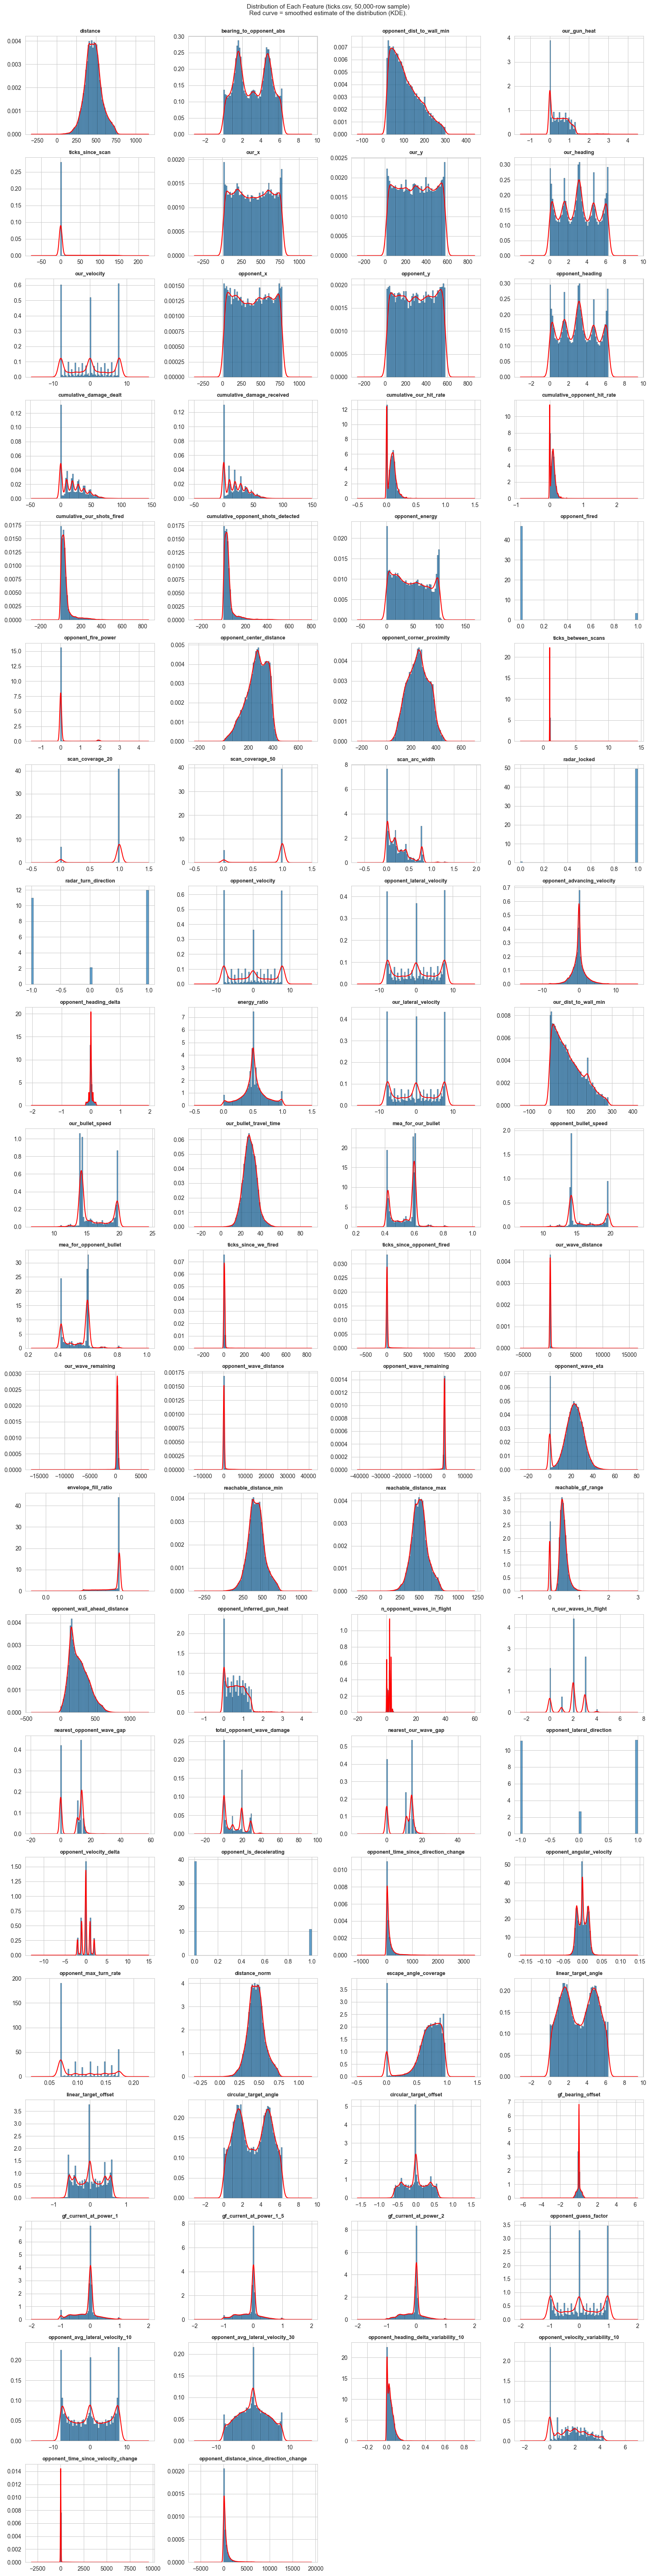

In [5]:
# --- Histograms of all numeric features in ticks.csv ---
# Plotting on the full ~1M-row frame is overkill: a 50-bin histogram looks the
# same with 50,000 points as with 1,000,000. We subsample once for plotting.
# Use the shared exclude list — it covers row keys plus per-battle constants
# (battlefield size, gun cooling, identity hashes) that live in scores.csv now.
from _loader import numeric_feature_cols
feature_cols = numeric_feature_cols(ticks)

PLOT_SAMPLE = 50_000
plot_df = ticks[feature_cols].sample(min(PLOT_SAMPLE, len(ticks)),
                                     random_state=42)

n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data = plot_df[col].dropna()
    if len(data) > 0:
        ax.hist(data, bins=50, alpha=0.7, edgecolor='black',
                linewidth=0.3, density=True)
        # KDE only if the column actually varies (avoid singular-matrix errors)
        if data.nunique() > 5 and data.std() > 1e-6:
            try:
                data.plot.kde(ax=ax, color='red', linewidth=1.5)
            except Exception:
                pass
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Distribution of Each Feature (ticks.csv, {PLOT_SAMPLE:,}-row sample)\n"
             f"Red curve = smoothed estimate of the distribution (KDE).",
             fontsize=11, y=1.0)
plt.tight_layout()
plt.show()


## Section 5 — Box Plots per Robot

A **box plot** (also called "box and whisker") summarizes a distribution in 5 numbers:

```
         ┌─────────┐
    ─────┤   BOX   ├─────   ●  ●
         └─────────┘
   min  Q1  median  Q3  max  outliers
   (whisker)       (whisker)
```

- **The box** spans from Q1 (25th percentile) to Q3 (75th percentile) — the middle 50% of values
- **The line inside the box** is the median (50th percentile)
- **Whiskers** extend to 1.5 × IQR from the box edges (IQR = Q3 − Q1)
- **Dots beyond the whiskers** are outliers — unusually extreme values

Comparing boxes across robots tells us: does Diamond keep a different distance than BeepBoop? Does DrussGT move laterally more?

C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(PER_ROBOT_SAMPLE, len(g)),
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


Box-plot sample: 100,000 rows (50 robots × ~2000 rows)


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax,


C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_4520\2887241452.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=80,


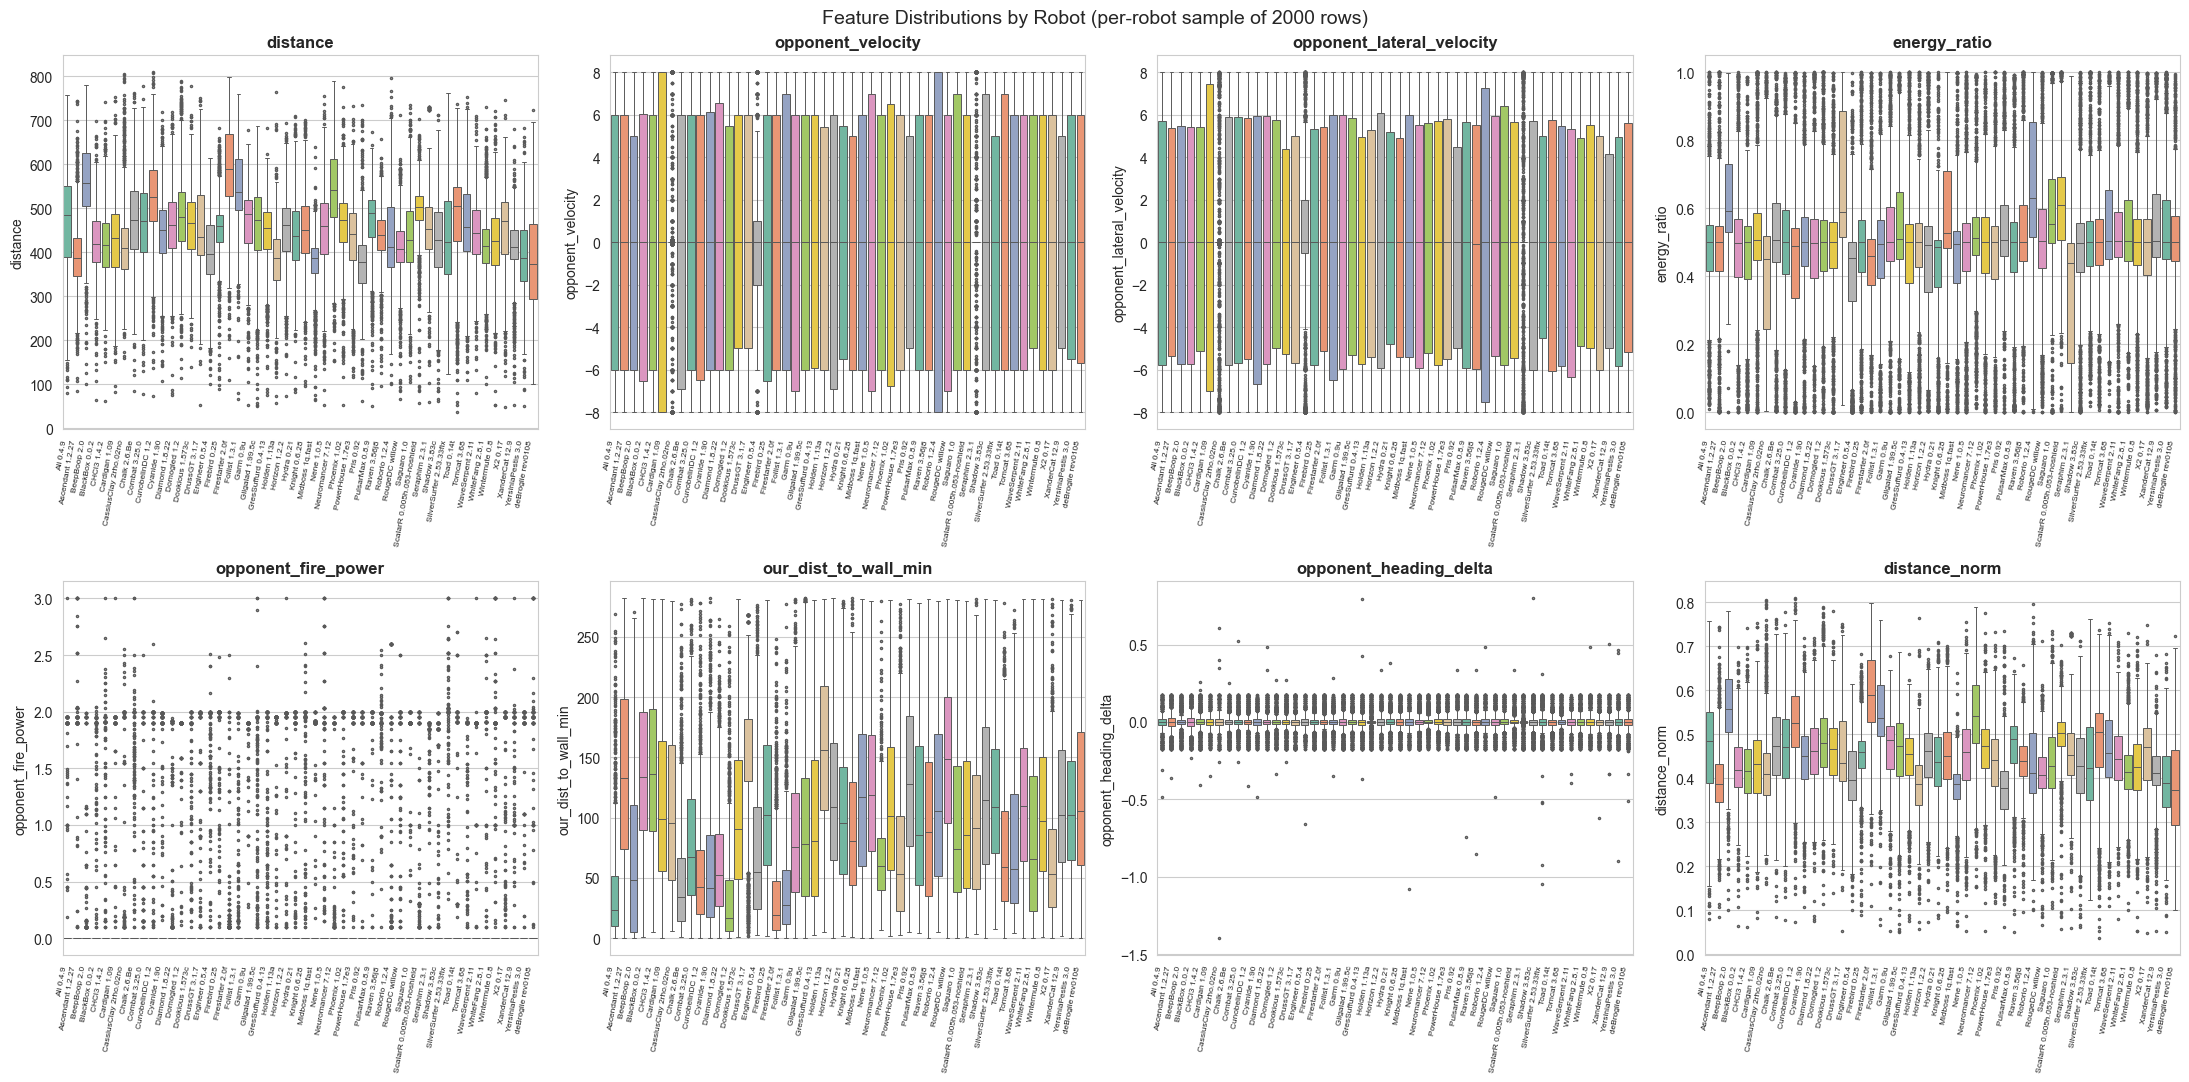

In [6]:
# --- Box plots of key features grouped by robot ---
# Subsample per robot so seaborn doesn't render millions of outlier glyphs.
key_features = ['distance', 'opponent_velocity', 'opponent_lateral_velocity',
                'energy_ratio', 'opponent_fire_power', 'our_dist_to_wall_min',
                'opponent_heading_delta', 'distance_norm']
key_features = [f for f in key_features if f in ticks.columns]

PER_ROBOT_SAMPLE = 2000
plot_ticks = (ticks.groupby('robot_name', group_keys=False)
                   .apply(lambda g: g.sample(min(PER_ROBOT_SAMPLE, len(g)),
                                             random_state=42)))
print(f"Box-plot sample: {len(plot_ticks):,} rows "
      f"({plot_ticks['robot_name'].nunique()} robots × ~{PER_ROBOT_SAMPLE} rows)")

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if i >= len(axes):
        break
    ax = axes[i]
    data = plot_ticks[['robot_name', col]].dropna()
    if len(data) > 0:
        sns.boxplot(data=data, x='robot_name', y=col, ax=ax,
                    palette='Set2', fliersize=1.5, linewidth=0.7)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=80,
                           ha='right', fontsize=6)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Robot "
             f"(per-robot sample of {PER_ROBOT_SAMPLE} rows)",
             fontsize=14)
plt.tight_layout()
plt.show()


## Section 6 — Time-Series: How a Battle Unfolds

Let's pick one battle and plot features over time. This shows the *dynamics* — how distance, energy, and other features change tick by tick.

Round boundaries are marked with vertical dashed lines.

Battle: 020e2202
Robots: ['ScalarR 0.005h.053-noshield']


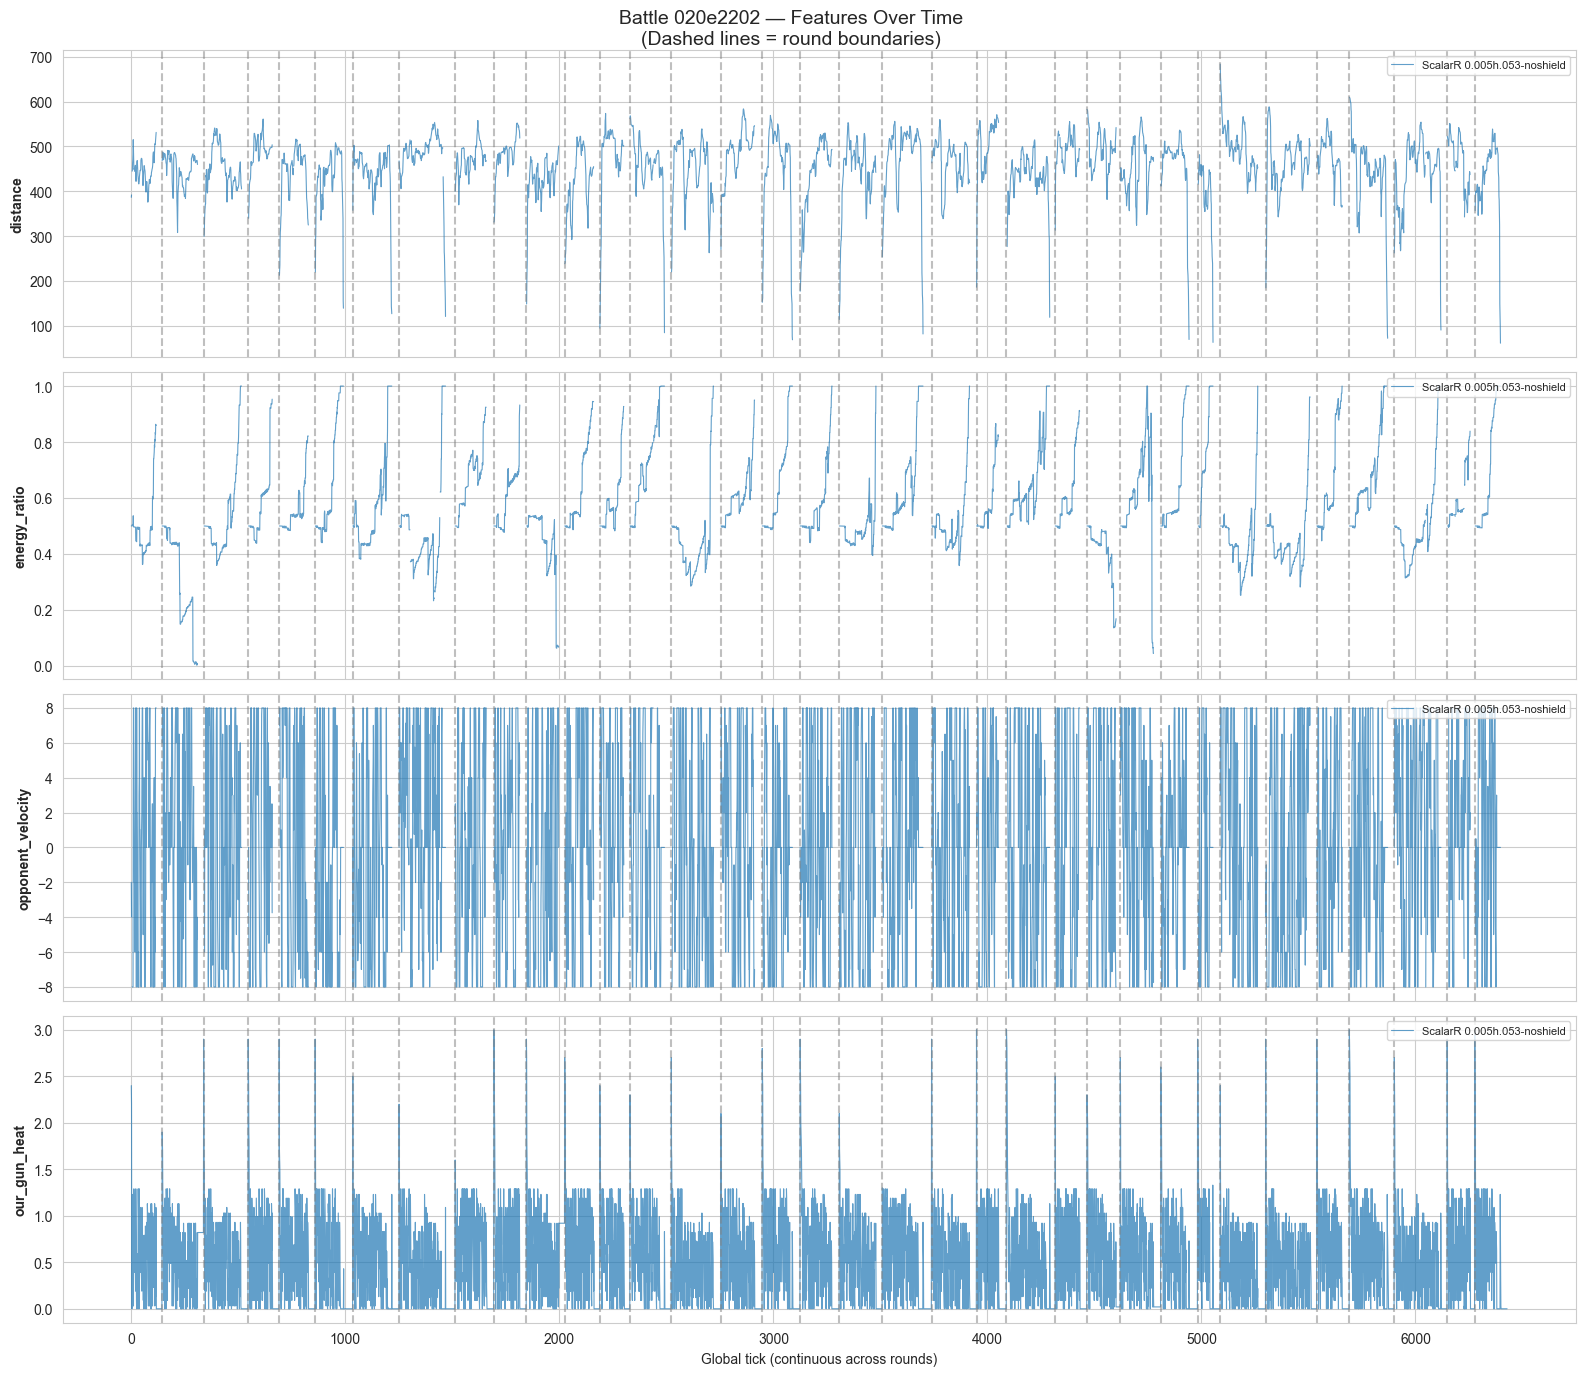

In [7]:
# --- Time series of one battle ---
# Pick the first battle_id
first_battle = ticks['battle_id'].unique()[0]
battle_data = ticks[ticks['battle_id'] == first_battle].copy()
robots_in_battle = battle_data['robot_name'].unique()

print(f"Battle: {first_battle}")
print(f"Robots: {robots_in_battle}")

# Create a continuous tick index (tick resets each round, so we make a global index)
battle_data = battle_data.sort_values(['robot_name', 'round', 'tick'])
battle_data['global_tick'] = battle_data.groupby('robot_name').cumcount()

time_features = ['distance', 'energy_ratio', 'opponent_velocity', 'our_gun_heat']
time_features = [f for f in time_features if f in battle_data.columns]

fig, axes = plt.subplots(len(time_features), 1, figsize=(16, 3.5 * len(time_features)), sharex=True)
if len(time_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, time_features):
    for robot in robots_in_battle:
        rdata = battle_data[battle_data['robot_name'] == robot]
        ax.plot(rdata['global_tick'], rdata[feat], label=robot, alpha=0.7, linewidth=0.8)
    
    # Mark round boundaries
    for robot in robots_in_battle[:1]:  # Use first robot for boundaries
        rdata = battle_data[battle_data['robot_name'] == robot]
        round_starts = rdata.groupby('round')['global_tick'].min()
        for rs in round_starts.values[1:]:  # Skip first round start
            ax.axvline(x=rs, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_ylabel(feat, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel("Global tick (continuous across rounds)")
fig.suptitle(f"Battle {first_battle} — Features Over Time\n(Dashed lines = round boundaries)", fontsize=14)
plt.tight_layout()
plt.show()

## Section 7 — Waves & Scores Overview

Quick look at bullet patterns and round outcomes.

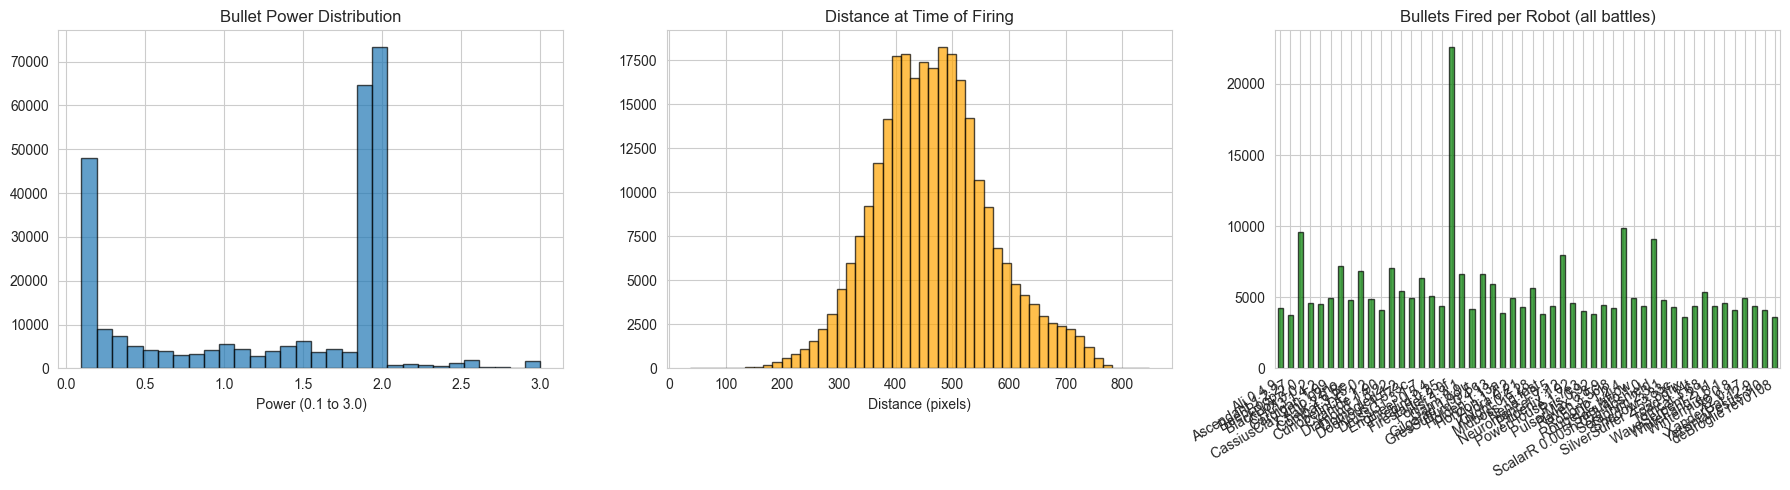

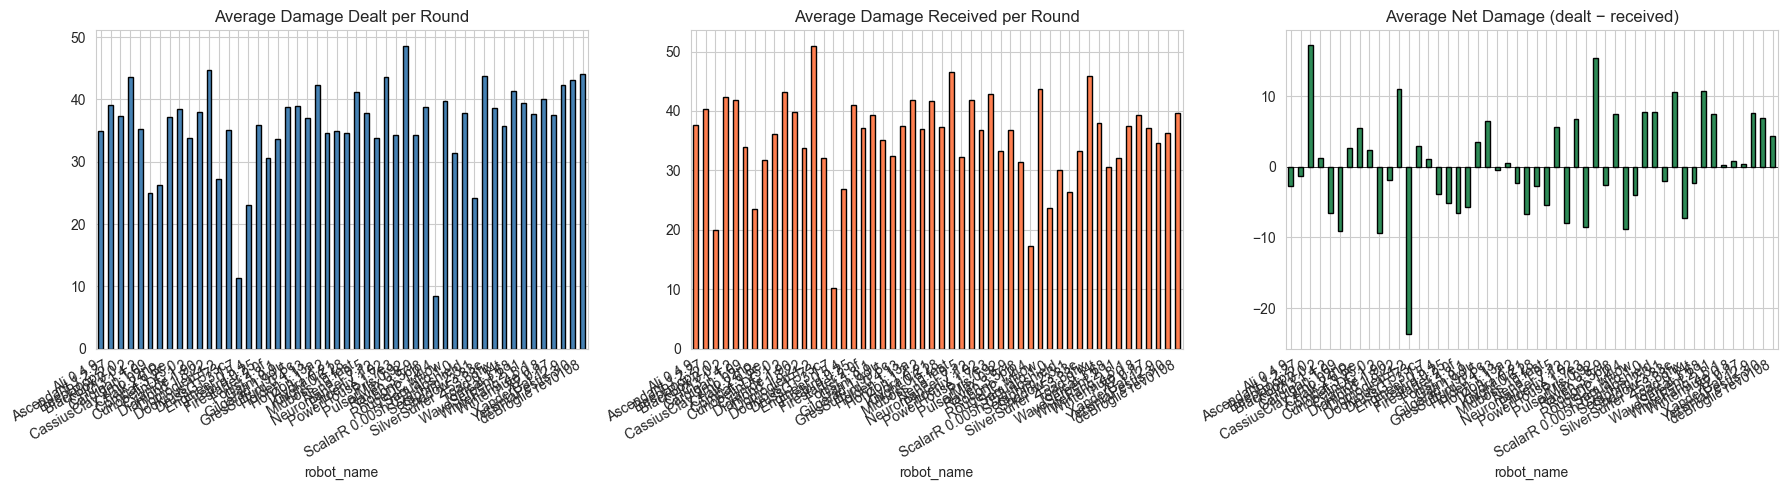

In [8]:
# --- Waves analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bullet power distribution
if 'wave_bullet_power' in waves.columns:
    axes[0].hist(waves['wave_bullet_power'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title("Bullet Power Distribution")
    axes[0].set_xlabel("Power (0.1 to 3.0)")

# Fire distance distribution
if 'wave_fire_distance' in waves.columns:
    axes[1].hist(waves['wave_fire_distance'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title("Distance at Time of Firing")
    axes[1].set_xlabel("Distance (pixels)")

# Waves per robot  
wave_counts = waves.groupby('robot_name').size()
wave_counts.plot.bar(ax=axes[2], color='green', edgecolor='black', alpha=0.7)
axes[2].set_title("Bullets Fired per Robot (all battles)")
axes[2].set_xlabel("")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# --- Scores analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Damage dealt per robot
scores.groupby('robot_name')['damage_dealt'].mean().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Average Damage Dealt per Round")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Damage received per robot
scores.groupby('robot_name')['damage_received'].mean().plot.bar(
    ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title("Average Damage Received per Round")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

# Net damage (positive = winning)
scores.groupby('robot_name')['net_damage'].mean().plot.bar(
    ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title("Average Net Damage (dealt − received)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()